In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
from sklearn.model_selection import train_test_split
import calendar
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import warnings
from google.colab import files



warnings.filterwarnings(
    "ignore",
    message="datetime.datetime.utcnow"
)





In [2]:

uploaded = files.upload()

Saving Retail_Transactions_Dataset.csv to Retail_Transactions_Dataset.csv


In [3]:
df = pd.read_csv("Retail_Transactions_Dataset.csv")

## 1) Descriptive Analysis


In [4]:
df.head(10)

,Transaction_ID,Date,Customer_Name,Product,Total_Items,Total_Cost,Payment_Method,City,Store_Type,Discount_Applied,Customer_Category,Season,Promotion
0,1000000000,2022-01-21 06:27:29,Stacey Price,"['Ketchup', 'Shaving Cream', 'Light Bulbs']",3,71.65,Mobile Payment,Los Angeles,Warehouse Club,True,Homemaker,Winter,NaN
1,1000000001,2023-03-01 13:01:21,Michelle Carlson,"['Ice Cream', 'Milk', 'Olive Oil', 'Bread', 'P...",2,25.93,Cash,San Francisco,Specialty Store,True,Professional,Fall,BOGO (Buy One Get One)
2,1000000002,2024-03-21 15:37:04,Lisa Graves,['Spinach'],6,41.49,Credit Card,Houston,Department Store,True,Professional,Winter,NaN
3,1000000003,2020-10-31 09:59:47,Mrs. Patricia May,"['Tissues', 'Mustard']",1,39.34,Mobile Payment,Chicago,Pharmacy,True,Homemaker,Spring,NaN
4,1000000004,2020-12-10 00:59:59,Susan Mitchell,['Dish Soap'],10,16.42,Debit Card,Houston,Specialty Store,False,Young Adult,Winter,Discount on Selected Items
5,1000000005,2021-10-07 12:37:26,Joshua Frazier,"['Toothpaste', 'Chicken']",3,72.24,Cash,Houston,Supermarket,True,Retiree,Spring,Discount on Selected Items
6,1000000006,2023-01-08 10:40:03,Victoria Garrett,"['Honey', 'BBQ Sauce', 'Soda', 'Olive Oil', 'G...",4,5.28,Cash,Boston,Specialty Store,False,Student,Summer,Discount on Selected Items
7,1000000007,2020-09-03 12:39:59,Sydney Waller,"['Syrup', 'Trash Cans', 'Pancake Mix', 'Water'...",5,21.77,Debit Card,Chicago,Specialty Store,False,Young Adult,Winter,Discount on Selected Items
8,1000000008,2021-04-05 06:32:18,Kimberly Morgan,['Insect Repellent'],4,55.25,Mobile Payment,Los Angeles,Warehouse Club,False,Homemaker,Fall,NaN
9,1000000009,2021-07-08 10:08:59,Lori Conway,"['Soap', 'Baby Wipes', 'Soda']",7,31.21,Mobile Payment,Boston,Convenience Store,True,Young Adult,Winter,NaN


In [5]:
df.columns



Index(['Transaction_ID', 'Date', 'Customer_Name', 'Product', 'Total_Items',
       'Total_Cost', 'Payment_Method', 'City', 'Store_Type',
       'Discount_Applied', 'Customer_Category', 'Season', 'Promotion'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 13 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   Transaction_ID     1000000 non-null  int64  
 1   Date               1000000 non-null  object 
 2   Customer_Name      1000000 non-null  object 
 3   Product            1000000 non-null  object 
 4   Total_Items        1000000 non-null  int64  
 5   Total_Cost         1000000 non-null  float64
 6   Payment_Method     1000000 non-null  object 
 7   City               1000000 non-null  object 
 8   Store_Type         1000000 non-null  object 
 9   Discount_Applied   1000000 non-null  bool   
 10  Customer_Category  1000000 non-null  object 
 11  Season             1000000 non-null  object 
 12  Promotion          666057 non-null   object 
dtypes: bool(1), float64(1), int64(2), object(9)
memory usage: 92.5+ MB


In [7]:
df[['Total_Items','Total_Cost']].describe()

,Total_Items,Total_Cost
count,1000000.000000,1000000.000000
mean,5.495941,52.455220
std,2.871654,27.416989
min,1.000000,5.000000
25%,3.000000,28.710000
50%,5.000000,52.420000
75%,8.000000,76.190000
max,10.000000,100.000000


In [8]:
print('Total Cities in Dataset: ',len(df['City'].unique()))
print(df['City'].value_counts(),end="\n\n")
print('1) Payment Methods',df['Payment_Method'].unique(),end="\n\n")
print('2) Customer Category',df['Customer_Category'].unique(),'| Total: ',len(df['Customer_Category'].unique()),end="\n\n")
print('3) Store Types',df['Store_Type'].unique(),'| Total: ',len(df['Customer_Category'].unique()))




Total Cities in Dataset:  10
City
Boston           100566
Dallas           100559
Seattle          100167
Chicago          100059
Houston          100050
New York         100007
Los Angeles       99879
Miami             99839
San Francisco     99808
Atlanta           99066
Name: count, dtype: int64

1) Payment Methods ['Mobile Payment' 'Cash' 'Credit Card' 'Debit Card']

2) Customer Category ['Homemaker' 'Professional' 'Young Adult' 'Retiree' 'Student'
 'Middle-Aged' 'Senior Citizen' 'Teenager'] | Total:  8

3) Store Types ['Warehouse Club' 'Specialty Store' 'Department Store' 'Pharmacy'
 'Supermarket' 'Convenience Store'] | Total:  8


**Observations:**


*   Columns: 13
*   Records (Rows) : 1M
*   Max Item(s) Purchase Cost: $ 100

*   Min Item(s) Purchase Cost: $ 5
*  Total Cities in Dataset: 10
*  Total Payment Methods Supported: 4 (Mobile Payment/Cash/Credit Card/Debit Card)
* Total Customers Categories : 8 | ['Homemaker' 'Professional' 'Young Adult' 'Retiree' 'Student'
 'Middle-Aged' 'Senior Citizen' 'Teenager']
 * Store Types: 8 | ['Warehouse Club' 'Specialty Store' 'Department Store' 'Pharmacy'
 'Supermarket' 'Convenience Store']


**Assumptions:**

The dataset is synthetic and generated for practice, not real retail decision-making.



1.   Transaction_ID is only a unique identifier and does not represent time order.
2.   The Date column is the only reliable source for time-based analysis.
3. The Product column reflects the actual items purchased;
Total_Items may be inconsistent and may need recalculation or removal.







In [9]:
num_cols = ['Total_Cost', 'Total_Items']

# Summary statistics
df[num_cols].describe()

,Total_Cost,Total_Items
count,1000000.000000,1000000.000000
mean,52.455220,5.495941
std,27.416989,2.871654
min,5.000000,1.000000
25%,28.710000,3.000000
50%,52.420000,5.000000
75%,76.190000,8.000000
max,100.000000,10.000000


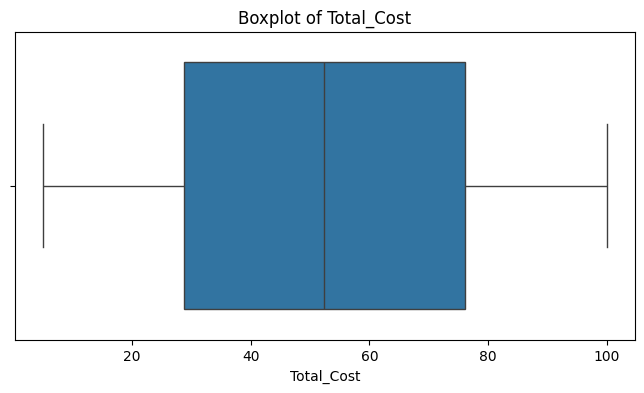

In [10]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['Total_Cost'])
plt.title('Boxplot of Total_Cost')
plt.xlabel('Total_Cost')
plt.show()

**Observation:**

The boxplot of Total_Cost shows a symmetric distribution with median around \$50 and interquartile range from ~\$30 to ~\$75.The whiskers extend to the minimum (\$10) and maximum (\$100), and no extreme outliers are observed. This uniform spread is expected due to the synthetic nature of the dataset


** Check Missing Values**



In [11]:
df.isnull().sum()

,0
Transaction_ID,0
Date,0
Customer_Name,0
Product,0
Total_Items,0
Total_Cost,0
Payment_Method,0
City,0
Store_Type,0
Discount_Applied,0


In [12]:
[features for features in df.columns if df[features].isnull().sum()>0]

['Promotion']

**Observation:** Only the Promotions column contain missing values.

## Univariat Analysis

Column: Promotion

Issue: Contains Missing

In [13]:
missing = df['Promotion'].isna().mean() *100
print("Missing values Percentage", missing, "%")


Missing values Percentage 33.3943 %


In [14]:
df['Promotion'] = df['Promotion'].fillna('No Promotion')
df.head()


,Transaction_ID,Date,Customer_Name,Product,Total_Items,Total_Cost,Payment_Method,City,Store_Type,Discount_Applied,Customer_Category,Season,Promotion
0,1000000000,2022-01-21 06:27:29,Stacey Price,"['Ketchup', 'Shaving Cream', 'Light Bulbs']",3,71.65,Mobile Payment,Los Angeles,Warehouse Club,True,Homemaker,Winter,No Promotion
1,1000000001,2023-03-01 13:01:21,Michelle Carlson,"['Ice Cream', 'Milk', 'Olive Oil', 'Bread', 'P...",2,25.93,Cash,San Francisco,Specialty Store,True,Professional,Fall,BOGO (Buy One Get One)
2,1000000002,2024-03-21 15:37:04,Lisa Graves,['Spinach'],6,41.49,Credit Card,Houston,Department Store,True,Professional,Winter,No Promotion
3,1000000003,2020-10-31 09:59:47,Mrs. Patricia May,"['Tissues', 'Mustard']",1,39.34,Mobile Payment,Chicago,Pharmacy,True,Homemaker,Spring,No Promotion
4,1000000004,2020-12-10 00:59:59,Susan Mitchell,['Dish Soap'],10,16.42,Debit Card,Houston,Specialty Store,False,Young Adult,Winter,Discount on Selected Items


**Conclusion:**

The Missing values in Promotion are now filled with "No Promotion"

### a) Categorical Analysis & Visualization

Column: City




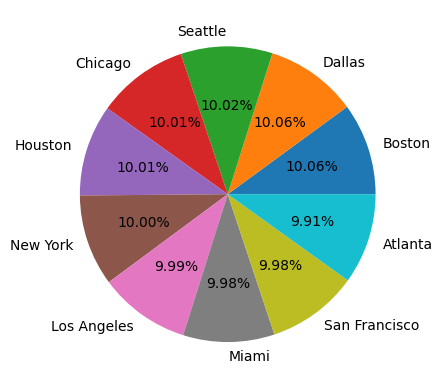

In [15]:
##Maximum Transactions w.r.t Cities

cities = df.City.value_counts().index
cities_values = df.City.value_counts().values
plt.pie(cities_values, labels=cities, autopct='%1.2f%%')
plt.show()

**Observation:** All the retail transactions are uniformly distributed among the cities."Dallas" and "Boston" are showing comparatively greater transaction percentages( 10.06%)


Column: Payment_Method

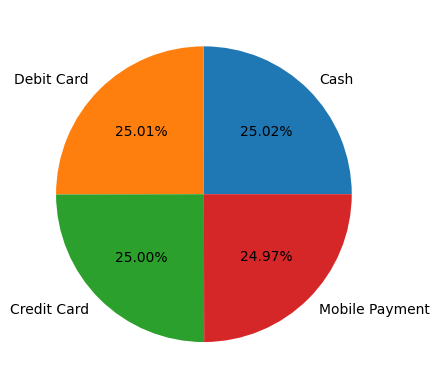

In [16]:
payment_method = df.Payment_Method.value_counts().index
payment_method_values = df.Payment_Method.value_counts().values
plt.pie(payment_method_values, labels=payment_method, autopct='%1.2f%%')
plt.show()

**Observation:**

The dataset contains four payment methods, all of which are used fairly uniformly, likely because the dataset is synthetic rather than real

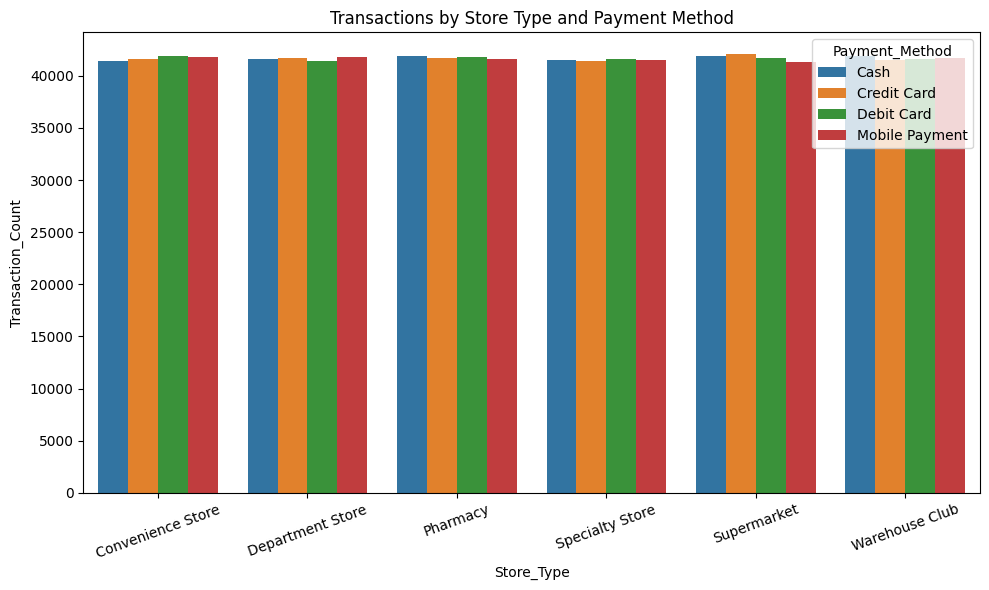

In [17]:
grouped = df.groupby(['Store_Type','Payment_Method']).size().reset_index(name='Transaction_Count')

plt.figure(figsize=(10,6))
sns.barplot(
    data=grouped,
    x='Store_Type',
    y='Transaction_Count',
    hue='Payment_Method'
)

plt.title('Transactions by Store Type and Payment Method')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

**Observation:**

To explore payment method preferences, I checked if usage varies across store types. In this dataset, payment methods appear fairly uniform across stores, likely because the data is synthetic. In real-world scenarios, we would expect payment method usage to differ between store types.

Column : Customer_Category


In [18]:
print('Total Categories',len(df['Customer_Category'].unique()),"\n",df['Customer_Category'].unique())

Total Categories 8 
 ['Homemaker' 'Professional' 'Young Adult' 'Retiree' 'Student'
 'Middle-Aged' 'Senior Citizen' 'Teenager']


In [19]:
df['Customer_Category'].value_counts()




,count
Customer_Category,
Senior Citizen,125485
Homemaker,125418
Teenager,125319
Retiree,125072
Student,124842
Professional,124651
Middle-Aged,124636
Young Adult,124577


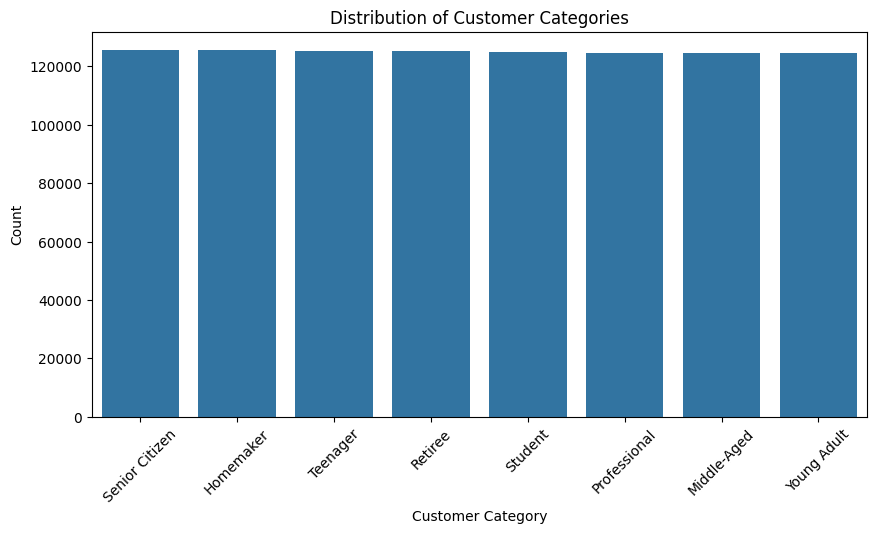

In [20]:
plt.figure(figsize=(10,5))  # slightly wider figure
sns.countplot(data=df, x='Customer_Category', order=df['Customer_Category'].value_counts().index)
plt.title('Distribution of Customer Categories')
plt.xlabel('Customer Category')
plt.ylabel('Count')
plt.xticks(rotation=45)  # rotate labels 45 degrees
plt.show()


**Observation:**

All 8 customer categories in the dataset have transactions that are fairly uniformly distributed, indicating no particular category dominates.

Column: Discount

In [21]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Year_Month'] = df['Date'].dt.to_period('M')
discounted_df = df[df['Discount_Applied'] == True]

monthly_discount_count = (
    discounted_df.groupby('Year_Month')
    .size()
    .reset_index(name='Discount_Count')
)



Month with maximum Discount:
2020-01 -> 9895 discounted transactions

Month with minimum Discount:
2024-05 -> 5542 discounted transactions


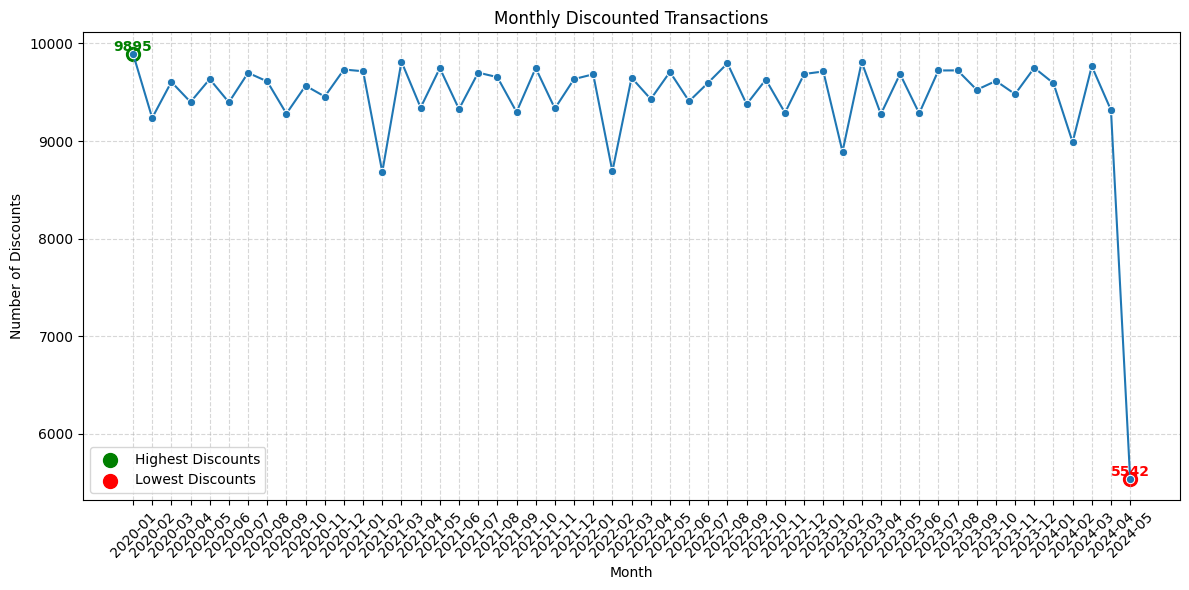

In [22]:
# Convert Year_Month to string for plotting
monthly_discount_count['Year_Month'] = monthly_discount_count['Year_Month'].astype(str)

# Find highest and lowest discount months
peak_idx = monthly_discount_count['Discount_Count'].idxmax()
low_idx = monthly_discount_count['Discount_Count'].idxmin()

peak_month = monthly_discount_count.loc[peak_idx, 'Year_Month']
peak_value = monthly_discount_count.loc[peak_idx, 'Discount_Count']

low_month = monthly_discount_count.loc[low_idx, 'Year_Month']
low_value = monthly_discount_count.loc[low_idx, 'Discount_Count']

print("Month with maximum Discount:")
print(f"{peak_month} -> {peak_value} discounted transactions\n")

print("Month with minimum Discount:")
print(f"{low_month} -> {low_value} discounted transactions")

# Plot the line
plt.figure(figsize=(12,6))
sns.lineplot(
    data=monthly_discount_count,
    x='Year_Month',
    y='Discount_Count',
    marker='o'
)

# Highlight highest discount month
plt.scatter(peak_month, peak_value, color='green', s=100, label='Highest Discounts')
plt.text(peak_month, peak_value, f'{peak_value}', color='green', fontweight='bold', ha='center', va='bottom')

# Highlight lowest discount month
plt.scatter(low_month, low_value, color='red', s=100, label='Lowest Discounts')
plt.text(low_month, low_value, f'{low_value}', color='red', fontweight='bold', ha='center', va='bottom')

plt.title('Monthly Discounted Transactions')
plt.xlabel('Month')
plt.ylabel('Number of Discounts')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


**Observation:**

* The highest number of discounted transactions occurred in Jan-2020 (9,895 transactions), while the lowest was in May-2024 (5,542 transactions).

* Discounts were most frequent at the beginning of the period and declined toward May-2024.

In [23]:
# Count transactions by Discount and Promotion
discount_promo = df.groupby(['Discount_Applied', 'Promotion']).size().reset_index(name='Count')
print(discount_promo)

   Discount_Applied                   Promotion   Count
0             False      BOGO (Buy One Get One)  166208
1             False  Discount on Selected Items  166504
2             False                No Promotion  167184
3              True      BOGO (Buy One Get One)  166479
4              True  Discount on Selected Items  166866
5              True                No Promotion  166759


**Observation:**

The distribution of discounted transactions across promotion types is fairly uniform, with similar counts for BOGO, Discount on Selected Items, and No Promotion. This indicates that in this dataset, discounts are not strongly linked to promotions. In real-world scenarios, we would typically expect discounts to be applied mainly during active promotions.

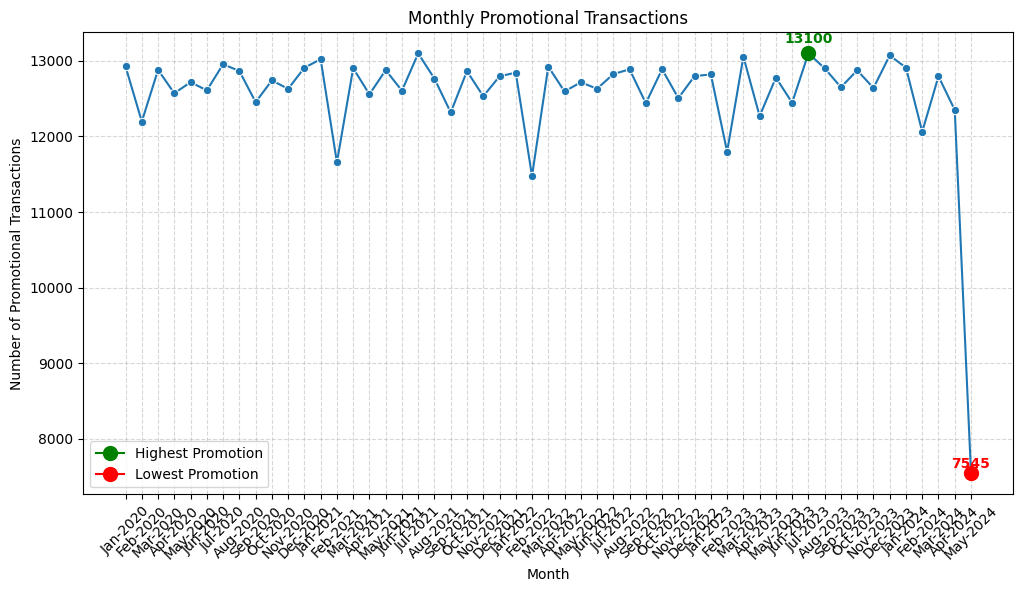

Month with Maximum Promotions: Jul-2023 -> 13100 transactions
Month with Minimum Promotions: May-2024 -> 7545 transactions


In [24]:

# Filter only transactions where Promotion is applied
promo_df = df[df['Promotion'] != 'No Promotion']  # or df['Promotion'] != False depending on your data

# Group by month and count
monthly_promo_count = promo_df.groupby('Year_Month').size().reset_index(name='Promotion_Count')
monthly_promo_count['Month_Year'] = monthly_promo_count['Year_Month'].dt.strftime('%b-%Y')

# Find highest and lowest promotion months
peak_idx = monthly_promo_count['Promotion_Count'].idxmax()
low_idx = monthly_promo_count['Promotion_Count'].idxmin()

peak_month = monthly_promo_count.loc[peak_idx, 'Month_Year']
peak_value = monthly_promo_count.loc[peak_idx, 'Promotion_Count']

low_month = monthly_promo_count.loc[low_idx, 'Month_Year']
low_value = monthly_promo_count.loc[low_idx, 'Promotion_Count']

# Plot line chart
plt.figure(figsize=(12,6))
sns.lineplot(data=monthly_promo_count, x='Month_Year', y='Promotion_Count', marker='o', linestyle='-')

# Highlight highest promotion month (green)
plt.plot(peak_month, peak_value, marker='o', markersize=10, color='green', label='Highest Promotion')
plt.text(peak_month, peak_value + peak_value*0.01, f'{peak_value}', color='green', fontweight='bold', ha='center')

# Highlight lowest promotion month (red)
plt.plot(low_month, low_value, marker='o', markersize=10, color='red', label='Lowest Promotion')
plt.text(low_month, low_value + low_value*0.01, f'{low_value}', color='red', fontweight='bold', ha='center')

plt.title('Monthly Promotional Transactions')
plt.xlabel('Month')
plt.ylabel('Number of Promotional Transactions')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

# Print concluding statement
print(f"Month with Maximum Promotions: {peak_month} -> {peak_value} transactions")
print(f"Month with Minimum Promotions: {low_month} -> {low_value} transactions")

**Observation:**

* Maximum promotions occurred in Jul-2023 (13,100 transactions)

 * Minimum in May-2024 (7,545 transactions)

* Promotions peaked mid-2023 and were lowest in May-2024.

 ### b) Numerical Analysis & Visualization

 Column Name: Total_Cost

Min Transaction Cost  : $5

Max Transaction Cost : $100

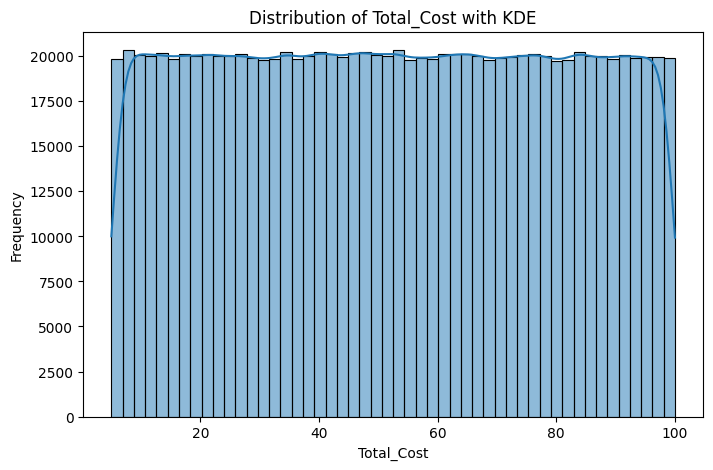

Skewness: 0.0015705322220765266


In [25]:
plt.figure(figsize=(8,5))
sns.histplot(df['Total_Cost'], bins=50, kde=True)
plt.title('Distribution of Total_Cost with KDE')
plt.xlabel('Total_Cost')
plt.ylabel('Frequency')
plt.show()
print('Skewness:', df['Total_Cost'].skew())


**Observation:**

The Total_Cost distribution appears rectangular (uniform-like) rather than bell-shaped. This is expected because the dataset is synthetic, and transaction totals are generated randomly rather than reflecting real-world purchasing patterns.


## 4) Feature Engineering


*   Recompute Total_Items from Product




In [26]:
type(df['Product'].iloc[0])

str

In [27]:
## Manipulating the Items Count w.r.t Product Column
df['Total_Items'] = df['Product'].apply(
    lambda x: len(ast.literal_eval(x)) if isinstance(x, str) else 0
)


In [28]:

df

,Transaction_ID,Date,Customer_Name,Product,Total_Items,Total_Cost,Payment_Method,City,Store_Type,Discount_Applied,Customer_Category,Season,Promotion,Year_Month
0,1000000000,2022-01-21 06:27:29,Stacey Price,"['Ketchup', 'Shaving Cream', 'Light Bulbs']",3,71.65,Mobile Payment,Los Angeles,Warehouse Club,True,Homemaker,Winter,No Promotion,2022-01
1,1000000001,2023-03-01 13:01:21,Michelle Carlson,"['Ice Cream', 'Milk', 'Olive Oil', 'Bread', 'P...",5,25.93,Cash,San Francisco,Specialty Store,True,Professional,Fall,BOGO (Buy One Get One),2023-03
2,1000000002,2024-03-21 15:37:04,Lisa Graves,['Spinach'],1,41.49,Credit Card,Houston,Department Store,True,Professional,Winter,No Promotion,2024-03
3,1000000003,2020-10-31 09:59:47,Mrs. Patricia May,"['Tissues', 'Mustard']",2,39.34,Mobile Payment,Chicago,Pharmacy,True,Homemaker,Spring,No Promotion,2020-10
4,1000000004,2020-12-10 00:59:59,Susan Mitchell,['Dish Soap'],1,16.42,Debit Card,Houston,Specialty Store,False,Young Adult,Winter,Discount on Selected Items,2020-12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,1000999995,2023-03-27 06:12:10,Lisa Gonzalez,"['Pickles', 'Carrots', 'Peanut Butter', 'Spong...",5,22.07,Debit Card,Los Angeles,Supermarket,False,Middle-Aged,Winter,No Promotion,2023-03
999996,1000999996,2022-05-19 05:13:58,Emily Graham,['Cereal'],1,80.25,Cash,Houston,Warehouse Club,True,Senior Citizen,Spring,Discount on Selected Items,2022-05
999997,1000999997,2021-09-03 13:59:39,Cynthia Anderson,['Trash Bags'],1,60.74,Credit Card,Los Angeles,Convenience Store,False,Homemaker,Winter,No Promotion,2021-09
999998,1000999998,2023-10-17 05:50:40,Michael Rodriguez,"['Diapers', 'Coffee', 'Coffee', 'Mop']",4,23.48,Debit Card,San Francisco,Supermarket,True,Retiree,Winter,BOGO (Buy One Get One),2023-10


**Conclusion:**

Now the Total_Items value is consistent with the actual Product list in the transaction


In [29]:
items_100 = df[df['Total_Cost'] == 100]
items_100

,Transaction_ID,Date,Customer_Name,Product,Total_Items,Total_Cost,Payment_Method,City,Store_Type,Discount_Applied,Customer_Category,Season,Promotion,Year_Month
8258,1000008258,2021-10-04 23:52:10,Sheila Lane,"['Lawn Mower', 'Honey', 'Sponges', 'Hair Gel',...",5,100.0,Credit Card,Seattle,Specialty Store,True,Homemaker,Winter,No Promotion,2021-10
8604,1000008604,2024-02-06 10:51:14,Jeffrey Frost,"['Cleaning Spray', 'Mop', 'Bread', 'Water']",4,100.0,Debit Card,San Francisco,Convenience Store,True,Middle-Aged,Winter,BOGO (Buy One Get One),2024-02
9004,1000009004,2023-10-09 10:37:35,Grace Hudson,"['Honey', 'Baby Wipes', 'Iron', 'Shampoo']",4,100.0,Mobile Payment,Miami,Supermarket,True,Professional,Fall,BOGO (Buy One Get One),2023-10
21018,1000021018,2022-11-01 20:12:16,Donna Leon,"['Iron', 'Ice Cream', 'Pancake Mix', 'Baby Wip...",4,100.0,Debit Card,New York,Pharmacy,False,Middle-Aged,Winter,No Promotion,2022-11
34316,1000034316,2020-08-20 04:39:01,Anthony Brown,['Ironing Board'],1,100.0,Cash,Los Angeles,Pharmacy,True,Retiree,Winter,BOGO (Buy One Get One),2020-08
140221,1000140221,2020-11-04 13:13:01,Jonathan Alvarez,"['Razors', 'Shampoo', 'Ironing Board']",3,100.0,Debit Card,Houston,Convenience Store,False,Young Adult,Winter,BOGO (Buy One Get One),2020-11
144459,1000144459,2024-04-13 13:21:40,Megan Logan,"['Plant Fertilizer', 'Ironing Board', 'Garden ...",3,100.0,Cash,Houston,Warehouse Club,False,Middle-Aged,Spring,BOGO (Buy One Get One),2024-04
148987,1000148987,2020-04-18 12:39:02,Ronald Chen,['Pasta'],1,100.0,Credit Card,Dallas,Warehouse Club,False,Retiree,Winter,Discount on Selected Items,2020-04
219055,1000219055,2023-01-13 16:43:32,John Roberts,"['Extension Cords', 'Trash Bags', 'Iron', 'Ext...",4,100.0,Credit Card,Boston,Supermarket,False,Middle-Aged,Spring,Discount on Selected Items,2023-01
229912,1000229912,2022-11-07 12:49:04,Elaine Mitchell,"['Extension Cords', 'Canned Soup']",2,100.0,Credit Card,Los Angeles,Supermarket,True,Homemaker,Winter,BOGO (Buy One Get One),2022-11


In [30]:
items_100.shape

(46, 14)

In [31]:
items_100 = df[df['Total_Cost'] == 5]
items_100

,Transaction_ID,Date,Customer_Name,Product,Total_Items,Total_Cost,Payment_Method,City,Store_Type,Discount_Applied,Customer_Category,Season,Promotion,Year_Month
3118,1000003118,2024-03-26 12:16:19,William Jones,"['Ketchup', 'Spinach', 'Toilet Paper', 'Coffee...",5,5.0,Credit Card,Houston,Department Store,False,Professional,Winter,BOGO (Buy One Get One),2024-03
5615,1000005615,2023-05-29 01:18:18,Paul Solis,"['Baby Wipes', 'Paper Towels', 'Jam', 'Bath To...",4,5.0,Debit Card,Atlanta,Department Store,False,Student,Winter,Discount on Selected Items,2023-05
16511,1000016511,2023-11-08 19:55:56,Mallory Herring,['Dustpan'],1,5.0,Debit Card,Dallas,Department Store,True,Young Adult,Fall,BOGO (Buy One Get One),2023-11
127317,1000127317,2020-11-17 22:28:46,Alicia Santos,"['Eggs', 'Spinach', 'Water', 'Potatoes']",4,5.0,Cash,Miami,Convenience Store,True,Senior Citizen,Spring,BOGO (Buy One Get One),2020-11
127362,1000127362,2021-07-01 06:10:25,Abigail Petersen,"['Power Strips', 'Carrots', 'Hand Sanitizer', ...",4,5.0,Cash,Atlanta,Pharmacy,True,Young Adult,Spring,BOGO (Buy One Get One),2021-07
134442,1000134442,2021-01-04 10:00:14,Alexander Bennett,"['Shrimp', 'Salmon', 'Mop', 'Mayonnaise', 'Cer...",5,5.0,Debit Card,Atlanta,Pharmacy,False,Retiree,Fall,BOGO (Buy One Get One),2021-01
151138,1000151138,2021-02-13 19:32:38,Kathy Rodriguez,['Hair Gel'],1,5.0,Credit Card,Atlanta,Supermarket,False,Student,Fall,BOGO (Buy One Get One),2021-02
175007,1000175007,2020-06-22 17:37:50,Kathy Robertson,"['Pasta', 'Cleaning Rags', 'Potatoes', 'Vacuum...",4,5.0,Cash,New York,Supermarket,False,Middle-Aged,Spring,BOGO (Buy One Get One),2020-06
186701,1000186701,2020-06-16 00:36:46,Paul Hall,"['Orange', 'Ketchup', 'Mop']",3,5.0,Mobile Payment,Houston,Warehouse Club,True,Professional,Winter,BOGO (Buy One Get One),2020-06
190013,1000190013,2020-04-30 13:52:40,Austin Brown,['Water'],1,5.0,Debit Card,Houston,Convenience Store,True,Middle-Aged,Spring,No Promotion,2020-04


In [32]:
items_100.shape

(54, 14)

##Sales Analysis


In [33]:
print(df['Date'].dtype)

datetime64[ns]


Month with maximum sales:
Month_Year         Mar-2023
Monthly_Sales    1033556.59
Name: 38, dtype: object


Month with minimum sales:
Month_Year        May-2024
Monthly_Sales    586965.49
Name: 52, dtype: object


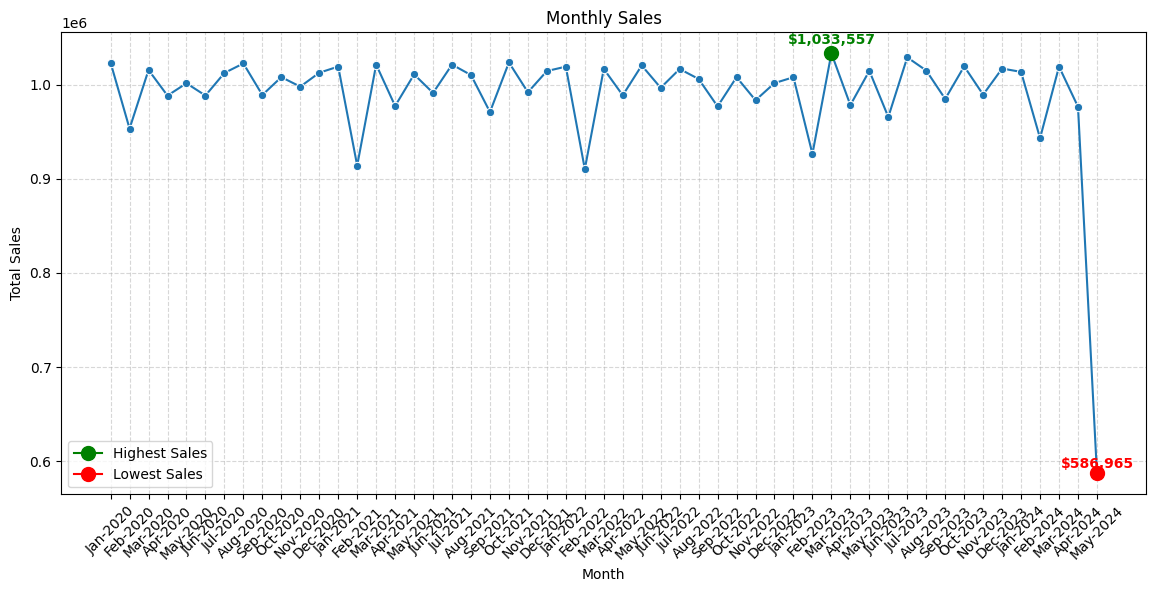

In [34]:
# Extract Year-Month period
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

df['Year_Month'] = df['Date'].dt.to_period('M')

# Group by Year-Month and sum Total_Cost
monthly_sales = df.groupby('Year_Month')['Total_Cost'].sum().reset_index()
monthly_sales.rename(columns={'Total_Cost': 'Monthly_Sales'}, inplace=True)

# Convert back to timestamp for plotting
monthly_sales['Date'] = monthly_sales['Year_Month'].dt.to_timestamp()
monthly_sales['Month_Year'] = monthly_sales['Date'].dt.strftime('%b-%Y')


max_sales_row = monthly_sales.loc[monthly_sales['Monthly_Sales'].idxmax()]
min_sales_row = monthly_sales.loc[monthly_sales['Monthly_Sales'].idxmin()]
print("Month with maximum sales:")
print(max_sales_row[['Month_Year', 'Monthly_Sales']])
print("\n")
print("Month with minimum sales:")
print(min_sales_row[['Month_Year', 'Monthly_Sales']])

# Find peak and lowest
peak_idx = monthly_sales['Monthly_Sales'].idxmax()
low_idx = monthly_sales['Monthly_Sales'].idxmin()

peak_month = monthly_sales.loc[peak_idx, 'Month_Year']
peak_value = monthly_sales.loc[peak_idx, 'Monthly_Sales']

low_month = monthly_sales.loc[low_idx, 'Month_Year']
low_value = monthly_sales.loc[low_idx, 'Monthly_Sales']

plt.figure(figsize=(14,6))

# Solid line with markers
sns.lineplot(data=monthly_sales, x='Month_Year', y='Monthly_Sales', marker='o', linestyle='-')

# Highlight highest peak (green)
plt.plot(peak_month, peak_value, marker='o', markersize=10, color='green', label='Highest Sales')
plt.text(peak_month, peak_value + peak_value*0.01, f'${peak_value:,.0f}',
         color='green', fontweight='bold', ha='center')

# Highlight lowest peak (red)
plt.plot(low_month, low_value, marker='o', markersize=10, color='red', label='Lowest Sales')
plt.text(low_month, low_value + low_value*0.01, f'${low_value:,.0f}',
         color='red', fontweight='bold', ha='center')

# Add grid lines
plt.grid(True, linestyle='--', alpha=0.5)

plt.title('Monthly Sales')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.legend()
plt.show()

**Observations:**

* The line chart shows the trend of monthly sales.

* The highest sales occurred in March 2023, reaching approximately $ 1033557, indicating a peak period for transactions during that month.

* The lowest sales occurred in May 2024, with around $586965, representing the slowest month in the dataset.

* Overall, the chart highlights significant fluctuations in monthly sales, suggesting seasonal or periodic trends that may be useful for forecasting and planning.

In [35]:
# Keep only March months
march_sales = df[df['Year_Month'].dt.month == 3]

# Group by Year_Month and sum Total_Cost
march_total_sales = march_sales.groupby('Year_Month')['Total_Cost'].sum().reset_index()

# Create a Month-Year column for plotting
march_total_sales['Month_Year'] = march_total_sales['Year_Month'].dt.strftime('%b-%Y')
march_total_sales

,Year_Month,Total_Cost,Month_Year
0,2020-03,1015781.37,Mar-2020
1,2021-03,1021530.14,Mar-2021
2,2022-03,1016946.28,Mar-2022
3,2023-03,1033556.59,Mar-2023
4,2024-03,1019427.01,Mar-2024


/tmp/ipython-input-3787799221.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  highest_lowest = monthly_sales.groupby('Year').apply(


   Year  level_1 Highest_Month  Highest_Sales Lowest_Month  Lowest_Sales
0  2020        0           Jan     1023565.45          Feb     953488.19
1  2021        0           Oct     1023812.22          Feb     914130.51
2  2022        0           May     1020629.00          Feb     910431.32
3  2023        0           Mar     1033556.59          Feb     926532.97
4  2024        0           Mar     1019427.01          May     586965.49


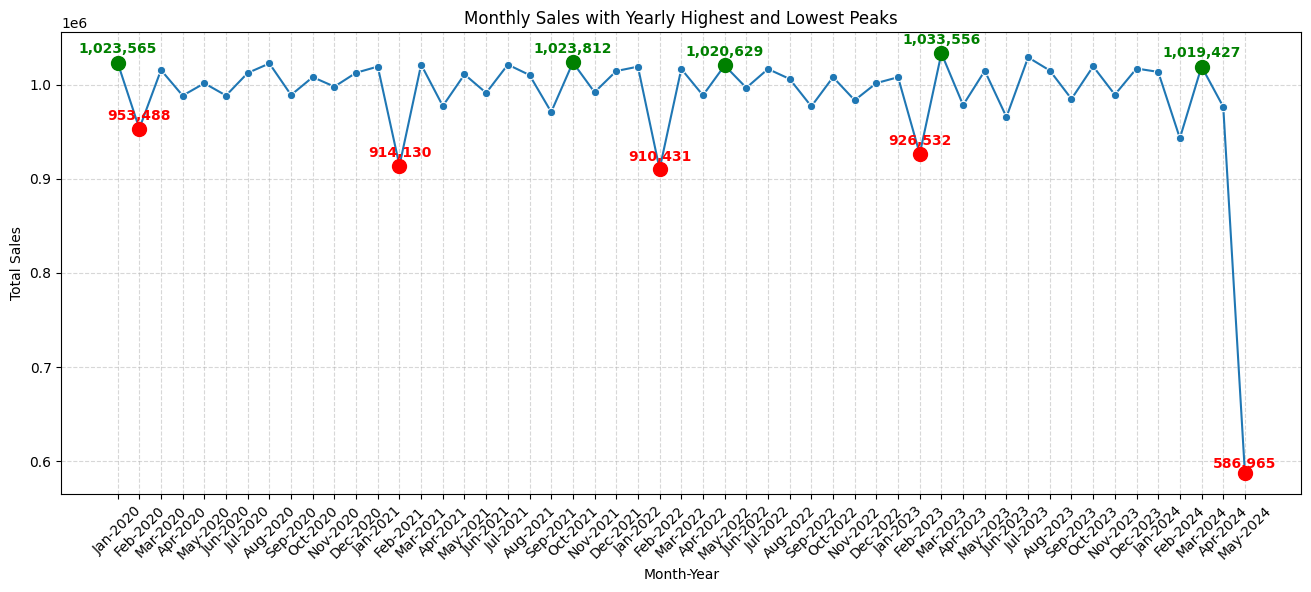

In [36]:
# Extract Year and Month
df['Year'] = df['Year_Month'].dt.year.astype(int)
df['Month'] = df['Year_Month'].dt.month.astype(int)

# Group by Year and Month and sum Total_Cost
monthly_sales = df.groupby(['Year','Month'])['Total_Cost'].sum().reset_index()

# Find highest and lowest month for each year
highest_lowest = monthly_sales.groupby('Year').apply(
    lambda x: pd.DataFrame({
        'Highest_Month': [x.loc[x['Total_Cost'].idxmax(), 'Month']],
        'Highest_Sales': [x['Total_Cost'].max()],
        'Lowest_Month': [x.loc[x['Total_Cost'].idxmin(), 'Month']],
        'Lowest_Sales': [x['Total_Cost'].min()]
    })
).reset_index(drop=False)  # keep Year column

# Convert month numbers to month names
highest_lowest['Highest_Month'] = highest_lowest['Highest_Month'].astype(int).apply(lambda x: calendar.month_abbr[x])
highest_lowest['Lowest_Month'] = highest_lowest['Lowest_Month'].astype(int).apply(lambda x: calendar.month_abbr[x])

print(highest_lowest)

# Create Month-Year labels for plotting
monthly_sales['Month_Year'] = monthly_sales.apply(
    lambda row: f"{calendar.month_abbr[int(row['Month'])]}-{int(row['Year'])}", axis=1
)

# Prepare peak and low points
peak_months = []
low_months = []

for idx, row in highest_lowest.iterrows():
    # Get Month-Year string for peaks
    peak_month_str = f"{row['Highest_Month']}-{row['Year']}"
    low_month_str = f"{row['Lowest_Month']}-{row['Year']}"

    # Get corresponding sales value
    peak_value = row['Highest_Sales']
    low_value = row['Lowest_Sales']

    peak_months.append((peak_month_str, peak_value))
    low_months.append((low_month_str, low_value))

# Plot line chart
plt.figure(figsize=(16,6))
sns.lineplot(data=monthly_sales, x='Month_Year', y='Total_Cost', marker='o', linestyle='-')

# Highlight yearly peaks (green) and troughs (red)
for month, value in peak_months:
    plt.plot(month, value, marker='o', markersize=10, color='green')
    plt.text(month, value + value*0.01, f'{int(value):,}', color='green', fontweight='bold', ha='center')

for month, value in low_months:
    plt.plot(month, value, marker='o', markersize=10, color='red')
    plt.text(month, value + value*0.01, f'{int(value):,}', color='red', fontweight='bold', ha='center')

plt.title('Monthly Sales with Yearly Highest and Lowest Peaks')
plt.xlabel('Month-Year')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**Observation:**

* Highest sales months vary: Jan (2020), Oct (2021), May (2022), Mar (2023), and Mar (2024).

* Lowest sales months are more consistent, with Feb appearing as the lowest in most years, except 2024 when it is May.

* This indicates that while peak sales months fluctuate each year, the lowest sales generally occur in the early months of the year.

##Why do sales peak during the first quarter (Jan–Mar) each year?

In [37]:
df['Year_Month'] = df['Date'].dt.to_period('M')

transactions = df.groupby('Year_Month').size().reset_index(name='Order_Count')
transactions.sort_values('Order_Count', ascending=False).head(10)

,Year_Month,Order_Count
38,2023-03,19658
18,2021-07,19605
42,2023-07,19579
47,2023-12,19490
0,2020-01,19486
14,2021-03,19482
12,2021-01,19447
24,2022-01,19444
28,2022-05,19444
50,2024-03,19426


**Conclusion:**

Number of transactions ≈ same (~19,400) for high-sales months and other months.Peaks are NOT because of more customers / more orders.



In [38]:
df['Year_Month'] = df['Date'].dt.to_period('M')

monthly = df.groupby('Year_Month').agg(
    Total_Sales=('Total_Cost','sum'),
    Orders=('Total_Cost','count'),
    Avg_Order_Value=('Total_Cost','mean')
).reset_index()

monthly.sort_values('Total_Sales', ascending=False).head(24)


,Year_Month,Total_Sales,Orders,Avg_Order_Value
38,2023-03,1033556.59,19658,52.576894
42,2023-07,1029246.18,19579,52.568884
21,2021-10,1023812.22,19390,52.801043
0,2020-01,1023565.45,19486,52.528248
7,2020-08,1022764.43,19362,52.823284
18,2021-07,1021536.65,19605,52.105925
14,2021-03,1021530.14,19482,52.434562
28,2022-05,1020629.00,19444,52.490691
45,2023-10,1019665.03,19407,52.541095
50,2024-03,1019427.01,19426,52.477453


**Observation:**

Because the dataset appears to be synthetic, monthly sales variations remain relatively small and stable. Peaks and lows are likely the result of random variation rather than true business events such as promotions or seasonal demand

##Investigate why Feb has Lower Sales.

In [39]:
df['Day'] = df['Date'].dt.day

daily = df.groupby('Date')['Total_Cost'].sum()

daily.mean(), daily.min(), daily.max()

(np.float64(52.64807028144091), 5.0, 217.42000000000002)

In [40]:
df.groupby(df['Date'].dt.month)['Total_Cost'].mean()

,Total_Cost
Date,
1,52.413914
2,52.397507
3,52.501505
4,52.431367
5,52.462129
6,52.418238
7,52.428713
8,52.580628
9,52.412727


**Observation:**

February shows the lowest total sales mainly because it has fewer days. The average daily sales remain consistent with other months, so the drop is due to fewer selling days rather than performance issues.

## Conclusion

The exploratory data analysis indicates that the dataset is synthetic in nature, which is reflected in the uniform distributions observed across numerical and categorical variables. Transaction costs, payment methods, store types, and customer categories show minimal variation and lack real-world fluctuations.

Unlike real retail datasets, no strong seasonal trends, promotional impacts, or demand-driven irregularities are observed. This uniformity is expected as the data has been programmatically generated rather than collected from real transactions.

Despite this limitation, the dataset is suitable for practicing EDA techniques, feature engineering, data visualization, and machine learning workflows, though insights should not be interpreted as real business behavior.

In [41]:
df[df['Customer_Name'] == 'William Jones']

,Transaction_ID,Date,Customer_Name,Product,Total_Items,Total_Cost,Payment_Method,City,Store_Type,Discount_Applied,Customer_Category,Season,Promotion,Year_Month,Year,Month,Day
3118,1000003118,2024-03-26 12:16:19,William Jones,"['Ketchup', 'Spinach', 'Toilet Paper', 'Coffee...",5,5.00,Credit Card,Houston,Department Store,False,Professional,Winter,BOGO (Buy One Get One),2024-03,2024,3,26
5171,1000005171,2020-02-25 08:16:17,William Jones,"['Ironing Board', 'Trash Bags']",2,89.81,Mobile Payment,New York,Specialty Store,True,Middle-Aged,Winter,No Promotion,2020-02,2020,2,25
15955,1000015955,2021-11-26 08:54:16,William Jones,"['Salmon', 'Toilet Paper', 'Extension Cords']",3,8.25,Credit Card,Chicago,Specialty Store,False,Teenager,Fall,Discount on Selected Items,2021-11,2021,11,26
25082,1000025082,2021-05-13 11:46:21,William Jones,"['Soda', 'Pickles', 'Vacuum Cleaner', 'Carrots...",5,65.43,Cash,Dallas,Specialty Store,False,Student,Winter,No Promotion,2021-05,2021,5,13
26668,1000026668,2023-02-08 23:41:45,William Jones,"['Toothpaste', 'Dishware']",2,39.27,Debit Card,San Francisco,Warehouse Club,True,Professional,Spring,No Promotion,2023-02,2023,2,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
975638,1000975638,2021-11-05 15:59:37,William Jones,"['Shrimp', 'Vinegar', 'Butter', 'Cleaning Rags...",5,51.49,Credit Card,Miami,Department Store,False,Homemaker,Summer,BOGO (Buy One Get One),2021-11,2021,11,5
975945,1000975945,2023-05-26 21:35:50,William Jones,"['Cleaning Rags', 'Ice Cream', 'Orange', 'Must...",4,59.31,Credit Card,New York,Specialty Store,True,Young Adult,Fall,Discount on Selected Items,2023-05,2023,5,26
984327,1000984327,2023-03-13 13:15:33,William Jones,"['Pickles', 'Baby Wipes', 'Toothbrush']",3,61.92,Credit Card,Boston,Warehouse Club,True,Young Adult,Spring,No Promotion,2023-03,2023,3,13
986058,1000986058,2020-01-11 01:43:39,William Jones,"['Yogurt', 'Lawn Mower', 'Chicken']",3,52.02,Cash,New York,Department Store,False,Middle-Aged,Spring,No Promotion,2020-01,2020,1,11


In [42]:
df['Transaction_Date'] = pd.to_datetime(df['Date'])
snapshot_date = df['Transaction_Date'].max() + pd.Timedelta(days=1)
rfm_cat = df.groupby('Customer_Category').agg({
    'Transaction_Date': lambda x: (snapshot_date - x.max()).days,
    'Transaction_ID': 'count',
    'Total_Cost': 'sum'
}).reset_index()

rfm_cat.columns = ['Customer_Category', 'Recency', 'Frequency', 'Monetary']


##Conclusion

Due to the absence of a consistent unique customer identifier, RFM analysis was performed at the customer category level. Recency was calculated based on the most recent transaction date per category, Frequency as the total number of transactions, and Monetary as the total revenue generated.

##RFM Scoring


In [43]:
# R score (lower recency = better)
rfm_cat['R_Score'] = pd.qcut(
    rfm_cat['Recency'].rank(method='first'),
    q=5,
    labels=[5, 4, 3, 2, 1]
)

rfm_cat['F_Score'] = pd.qcut(
    rfm_cat['Frequency'].rank(method='first'),
    q=5,
    labels=[1, 2, 3, 4, 5]
)

rfm_cat['M_Score'] = pd.qcut(
    rfm_cat['Monetary'].rank(method='first'),
    q=5,
    labels=[1, 2, 3, 4, 5]
)



rfm_cat['RFM_Score'] = (
    rfm_cat['R_Score'].astype(str) +
    rfm_cat['F_Score'].astype(str) +
    rfm_cat['M_Score'].astype(str)
)

def rfm_segment(row):
    if int(row['R_Score']) >= 4 and int(row['F_Score']) >= 4 and int(row['M_Score']) >= 4:
        return 'High Value'
    elif int(row['R_Score']) >= 3 and int(row['F_Score']) >= 3:
        return 'Medium Value'
    else:
        return 'Low Value'

rfm_cat['Segment'] = rfm_cat.apply(rfm_segment, axis=1)
rfm_cat[['Customer_Category','Recency','Frequency','Monetary','RFM_Score','Segment']]

,Customer_Category,Recency,Frequency,Monetary,RFM_Score,Segment
0,Homemaker,1,125418,6579605.97,555,High Value
1,Middle-Aged,1,124636,6532337.04,511,Low Value
2,Professional,1,124651,6547388.77,422,Low Value
3,Retiree,1,125072,6558223.95,333,Medium Value
4,Senior Citizen,1,125485,6568220.19,354,Medium Value
5,Student,1,124842,6552706.16,233,Low Value
6,Teenager,1,125319,6582893.18,145,Low Value
7,Young Adult,1,124577,6533845.14,111,Low Value


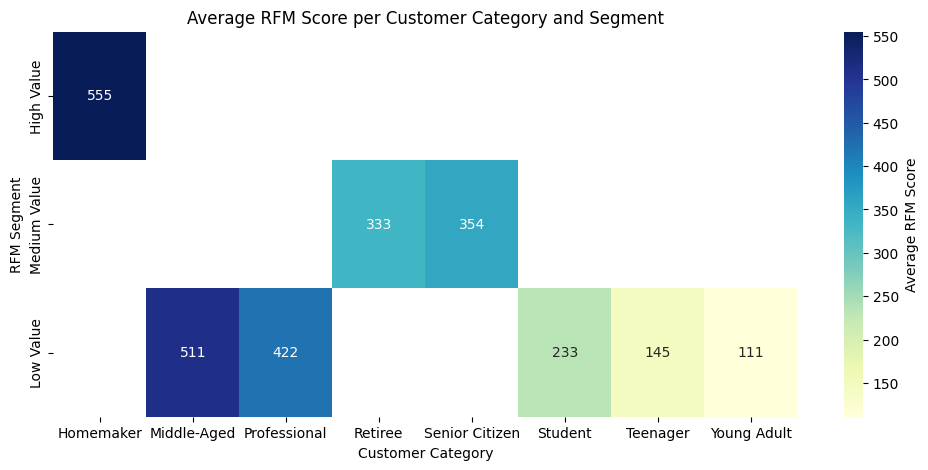

In [44]:
# Convert RFM_Score to numeric for averaging
rfm_cat['RFM_Score_Num'] = rfm_cat['RFM_Score'].astype(int)

# Pivot table: segments as rows, categories as columns, average RFM score as values
heat_data = rfm_cat.pivot_table(
    index='Segment',
    columns='Customer_Category',
    values='RFM_Score_Num',
    aggfunc='mean'
)

# Optional: reorder segments so Low -> Medium -> High
heat_data = heat_data.reindex(['High Value','Medium Value','Low Value'])

plt.figure(figsize=(12,5))
sns.heatmap(
    heat_data,
    annot=True,      # show numbers in each cell
    fmt=".0f",       # no decimals
    cmap="YlGnBu",   # color palette
    cbar_kws={'label': 'Average RFM Score'}
)

plt.title('Average RFM Score per Customer Category and Segment')
plt.ylabel('RFM Segment')
plt.xlabel('Customer Category')
plt.show()

## Heat Map interpretation

From the heatmap, we can see how different customer categories are distributed across RFM segments:

* Homemakers appear in the High Value segment with a high RFM score, indicating they have low recency (recently active), high frequency, and high monetary value.

* Middle-Aged and Professionals show a bluish tone in the heatmap, which reflects their high Recency score (they have made recent purchases). However, their Frequency and Monetary values are comparatively lower, which places them in the Low Value segment despite appearing recent.

* Retirees and Senior Citizens fall into the Medium Value segment, indicating moderate engagement and spending.

* Students, Teenagers, and Young Adults are also in the Low Value segment, suggesting they have lower frequency and monetary contributions even if some purchases are recent.

## Insights
* Businesses should focus on **Homemakers** as primary **high-value customers**
 * **Middle-Aged** and **Professionals** may need targeted engagement strategies (e.g., loyalty programs or personalized offers) to improve their frequency and spending.



## Market Basket Analysis

In [45]:
df['Total_Items'] = df['Product'].apply(
    lambda x: len(ast.literal_eval(x)) if isinstance(x, str) else 0
)


In [46]:
# Sample 10% of transactions to reduce memory usage
df_sample = df.sample(frac=0.1, random_state=42)

print(f"Sampled {len(df_sample)} transactions for Market Basket Analysis")

Sampled 100000 transactions for Market Basket Analysis


In [47]:
customer_categories = df_sample['Customer_Category'].unique()


In [48]:
def run_mba_by_category(df, min_support=0.05):
    # Ensure Product column is list
    df = df.copy()
    df['Product'] = df['Product'].apply(
        lambda x: ast.literal_eval(x) if isinstance(x, str) else x
    )

    te = TransactionEncoder()
    te_ary = te.fit(df['Product']).transform(df['Product'])
    encoded_df = pd.DataFrame(te_ary, columns=te.columns_)

    frequent_itemsets = apriori(
        encoded_df,
        min_support=min_support,
        use_colnames=True
    )

    rules = association_rules(
        frequent_itemsets,
        metric="lift",
        min_threshold=1.0
    )

    return rules.sort_values(by='lift', ascending=False)

In [49]:
category_rules = {}

for category in customer_categories:
    cat_df = df_sample[df_sample['Customer_Category'] == category]

    # Skip very small categories
    if len(cat_df) < 5000:
        continue

    print(f"Running MBA for: {category} | Records: {len(cat_df)}")

    category_rules[category] = run_mba_by_category(
        cat_df,
        min_support=0.05
    )


Running MBA for: Middle-Aged | Records: 12386
Running MBA for: Teenager | Records: 12444
Running MBA for: Homemaker | Records: 12584
Running MBA for: Professional | Records: 12564
Running MBA for: Young Adult | Records: 12338
Running MBA for: Senior Citizen | Records: 12663
Running MBA for: Retiree | Records: 12517
Running MBA for: Student | Records: 12504


In [50]:
segment_sales = (
    df.groupby('Customer_Category')['Total_Cost']
      .sum()
      .reset_index()
      .sort_values(by='Total_Cost', ascending=False)
)

segment_sales

,Customer_Category,Total_Cost
6,Teenager,6582893.18
0,Homemaker,6579605.97
4,Senior Citizen,6568220.19
3,Retiree,6558223.95
5,Student,6552706.16
2,Professional,6547388.77
7,Young Adult,6533845.14
1,Middle-Aged,6532337.04


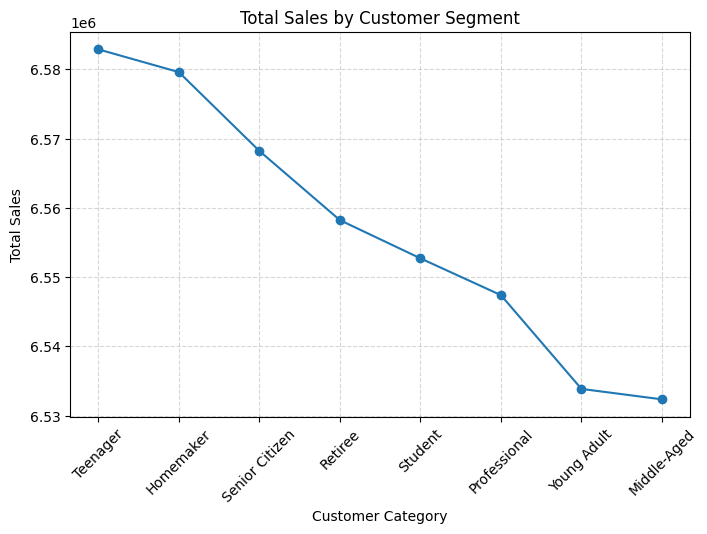

In [51]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))


plt.plot(
    segment_sales['Customer_Category'],
    segment_sales['Total_Cost'],
    marker='o',
    linestyle='-'
)

plt.title('Total Sales by Customer Segment')
plt.xlabel('Customer Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

## Insight

The Teenager customer segment contributes the highest total sales among all customer categories. This indicates strong purchasing activity and higher transaction volume within this segment compared to others.

In [52]:
df_teen = df[df['Customer_Category'] == 'Teenager']

print(f"Teenager segment transactions: {len(df_teen)}")

Teenager segment transactions: 125319


In [53]:
df_teen['Product'] = df_teen['Product'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)
te = TransactionEncoder()

te_ary = te.fit(df_teen['Product']).transform(df_teen['Product'])
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

# Check shape
print(df_encoded.shape)
df_encoded.head()

(125319, 81)


/tmp/ipython-input-569970170.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_teen['Product'] = df_teen['Product'].apply(


,Air Freshener,Apple,BBQ Sauce,Baby Wipes,Banana,Bath Towels,Beef,Bread,Broom,Butter,...,Tomatoes,Toothbrush,Toothpaste,Trash Bags,Trash Cans,Tuna,Vacuum Cleaner,Vinegar,Water,Yogurt
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,True,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [54]:
from mlxtend.frequent_patterns import apriori, association_rules

# Frequent itemsets (min_support = 0.05 -> items bought together in at least 5% of transactions)
frequent_itemsets = apriori(df_encoded, min_support=0.01, use_colnames=True)

# Sort by support
frequent_itemsets = frequent_itemsets.sort_values(by='support', ascending=False)
frequent_itemsets.head(10)

,support,itemsets
73,0.069614,(Toothpaste)
63,0.037448,(Soap)
45,0.037065,(Olive Oil)
52,0.036914,(Pickles)
46,0.036906,(Onions)
9,0.036794,(Butter)
4,0.036770,(Banana)
47,0.036730,(Orange)
8,0.036706,(Broom)
50,0.036690,(Pasta)


In [55]:
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(lambda x: len(x))
print(frequent_itemsets.head(10))

     support      itemsets  length
73  0.069614  (Toothpaste)       1
63  0.037448        (Soap)       1
45  0.037065   (Olive Oil)       1
52  0.036914     (Pickles)       1
46  0.036906      (Onions)       1
9   0.036794      (Butter)       1
4   0.036770      (Banana)       1
47  0.036730      (Orange)       1
8   0.036706       (Broom)       1
50  0.036690       (Pasta)       1


In [56]:
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)

# Sort by lift to see strongest associations
rules = rules.sort_values(by='lift', ascending=False)
rules[['antecedents','consequents','support','confidence','lift']].head(2)

,antecedents,consequents,support,confidence,lift


## Insight

Although Teenager Segment is the Frequent buyer but we can't drive any association rules becuase most of the transactions only contain single item purchase.

In [57]:
# Convert Product strings to lists if needed
df['Product'] = df['Product'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# Keep only transactions with 2 or more items
df_multi = df[df['Product'].apply(lambda x: len(x) >= 2)]
print(f"Transactions with 2+ items: {len(df_multi)}")

Transactions with 2+ items: 800270


In [58]:
te = TransactionEncoder()
te_ary = te.fit(df_multi['Product']).transform(df_multi['Product'])
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)
print(f"Encoded shape: {df_encoded.shape}")

Encoded shape: (800270, 81)


In [59]:
df_encoded

,Air Freshener,Apple,BBQ Sauce,Baby Wipes,Banana,Bath Towels,Beef,Bread,Broom,Butter,...,Tomatoes,Toothbrush,Toothpaste,Trash Bags,Trash Cans,Tuna,Vacuum Cleaner,Vinegar,Water,Yogurt
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
4,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
800265,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
800266,False,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
800267,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
800268,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


/tmp/ipython-input-3264952176.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_multi['Product'] = df_multi['Product'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
/tmp/ipython-input-3264952176.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_multi['Product_Length'] = df_multi['Product'].apply(len)


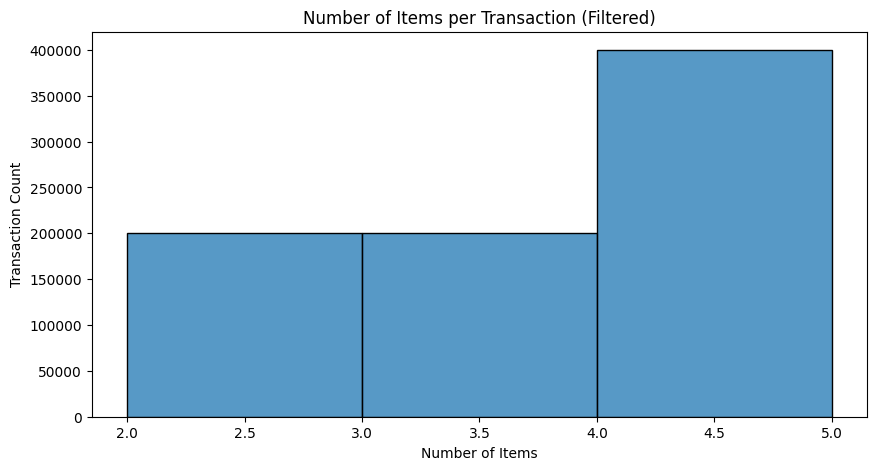

In [60]:
# 1️⃣ Confirm Product column is list
df_multi['Product'] = df_multi['Product'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# 2️⃣ Optional: Check distribution of items per transaction
df_multi['Product_Length'] = df_multi['Product'].apply(len)
plt.figure(figsize=(10,5))
sns.histplot(df_multi['Product_Length'], bins=range(2, df_multi['Product_Length'].max()+1), kde=False)
plt.title('Number of Items per Transaction (Filtered)')
plt.xlabel('Number of Items')
plt.ylabel('Transaction Count')
plt.show()



In [61]:
te = TransactionEncoder()
te_ary = te.fit(df_multi['Product']).transform(df_multi['Product'])
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)
print(f"Encoded shape: {df_encoded.shape}")

Encoded shape: (800270, 81)


In [62]:
frequent_itemsets = apriori(df_encoded, min_support=0.005, use_colnames=True)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(lambda x: len(x))
frequent_itemsets_multi = frequent_itemsets[frequent_itemsets['length'] >= 2]
print(f"Multi-item frequent itemsets: {len(frequent_itemsets_multi)}")

Multi-item frequent itemsets: 0


In [63]:
df['Product'] = df['Product'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# Count transactions with 2 or more items
multi_item_count = (df['Product'].apply(len) >= 2).sum()

# Total transactions
total_transactions = len(df)

# Percentage
multi_item_percent = (multi_item_count / total_transactions) * 100

print(f"Transactions with 2 or more items: {multi_item_count} ({multi_item_percent:.2f}%)")


Transactions with 2 or more items: 800270 (80.03%)


## Conclusion

Although 80% of the transactions contain two or more items, indicating that **the dataset is fairly dense in terms of transaction size, the occurrence of specific multi-item combinations is sparse.**
As a result, no frequent multi-item itemsets meet the minimum support threshold, and we are unable to generate meaningful association rules using standard Apriori settings.
This highlights that while customers buy multiple items per transaction, the variety of combinations is high, making repeated patterns rare.